# BTC Signal Classifier — Baseline MVP

**Strategy 1 | Binary Labels | No Regime Filter (Baseline)**


## 1 — Imports

In [45]:
#!pip install matplotlib --quiet

In [46]:
import pandas as pd
import pandas_ta as ta
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
from sklearn import set_config

from lightgbm import LGBMClassifier
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

set_config(display='diagram')

## 2 — Load Data & Feature Engineering

In [47]:
df = pd.read_csv('btc_1hour_cleaned.csv')

df['Open time']  = pd.to_datetime(df['Open time'])
df['Close time'] = pd.to_datetime(df['Close time'])
df = df.set_index('Open time')

print(f"Dataset shape: {df.shape}")
df.head(2)

Dataset shape: (71588, 11)


,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
Open time,,,,,,,,,,,
2018-01-01 00:00:00,13715.65,13715.65,13400.01,13529.01,443.356199,2018-01-01 00:59:59.999,5.993910e+06,5228,228.521921,3.090541e+06,0
2018-01-01 01:00:00,13528.99,13595.89,13155.38,13203.06,383.697006,2018-01-01 01:59:59.999,5.154522e+06,4534,180.840403,2.430449e+06,0


In [48]:
# ROC — Rate of Change
def compute_roc(df):
    df['roc_10'] = df['Close'].pct_change(periods=10)
    df['roc_21'] = df['Close'].pct_change(periods=21)
    return df

# MACD Histogram
def compute_macd(df):
    macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    df['macd_histogram'] = macd['MACDh_12_26_9']
    return df

# ADX — used as feature AND for regime detection (execution layer)
def compute_adx(df):
    df['adx'] = ta.adx(df['High'], df['Low'], df['Close'], length=14)['ADX_14']
    return df

# SMA 50 and SMA 200 — regime detection only, NOT in feature matrix X
def compute_regime(df):
    df['sma_50']  = df['Close'].rolling(50).mean()
    df['sma_200'] = df['Close'].rolling(200).mean()
    df['regime']  = (df['sma_50'] > df['sma_200']).astype(int).replace(0, -1)
    return df

# ATR 14 — required for label construction in MVP v2
def compute_atr(df):
    df['atr_14'] = ta.atr(df['High'], df['Low'], df['Close'], length=14)
    return df

# NATR — Normalised ATR
def compute_natr(df):
    df['natr'] = ta.natr(df['High'], df['Low'], df['Close'], length=14)
    return df


def feature_pipeline(df):
    steps = [
        compute_roc,
        compute_macd,
        compute_adx,
        compute_atr,
        compute_natr,
        compute_regime,    # execution layer only — does NOT go into X
    ]
    for step in steps:
        df = step(df)
    return df


df = feature_pipeline(df)

print(f"Shape after feature engineering: {df.shape}")
df.head(3)

Shape after feature engineering: (71588, 20)


,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore,roc_10,roc_21,macd_histogram,adx,atr_14,natr,sma_50,sma_200,regime
Open time,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,13715.65,13715.65,13400.01,13529.01,443.356199,2018-01-01 00:59:59.999,5.993910e+06,5228,228.521921,3.090541e+06,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
2018-01-01 01:00:00,13528.99,13595.89,13155.38,13203.06,383.697006,2018-01-01 01:59:59.999,5.154522e+06,4534,180.840403,2.430449e+06,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
2018-01-01 02:00:00,13203.00,13418.43,13200.00,13330.18,429.064572,2018-01-01 02:59:59.999,5.710192e+06,4887,192.237935,2.558505e+06,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1


## 3 — Label Construction & Feature Matrix

**Baseline (MVP v1):** simple binary label — `forward_return > 0`  
**MVP v2 (next step):** ATR-threshold label replaces this

---

### ✅ Change 1 — `y` as Series

| | Previous version | This version |
|---|---|---|
| Code | `y = df[['label']]` | `y = df['y']` |
| Type | `DataFrame` — 2D, shape `(n, 1)` | `Series` — 1D, shape `(n,)` |
| Problem | LightGBM raises `UserWarning`, some callbacks fail | Correct sklearn convention |

Double brackets `[[...]]` always return a DataFrame. Single bracket `[...]` returns a Series.

### ✅ Change 2 — Target column named `df['y']`

Naming the target column `'y'` avoids confusion between `df['label']` (the ground truth stored in the DataFrame) and `y_pred` (the model's predicted labels). Both would be called "label" — hard to tell apart at a glance.

In [49]:
# Lookahead horizon in bars
# To be IC-validated in MVP v2 — tested values: 5, 12, 24, 48
N = 5

# Forward return: how much did price move in the next N bars?
# IMPORTANT: forward_return must NEVER appear in X — lookahead bias
df['forward_return'] = df['Close'].pct_change(periods=N).shift(-N)

# ✅ Change 2: target column named 'y' (not 'label')
# Baseline label: BUY=1 if price moved up, FLAT=0 otherwise
# MVP v2: replace with ATR-threshold label
df['y'] = (df['forward_return'] > 0).astype(int)


# ── Lag features ───────────────────────────────────────────────────────────
# LightGBM has no memory — lags encode the time series structure
# Each indicator gets 5 lagged versions: lag1 = previous bar, lag5 = 5 bars ago

N_lags = 5
feature_cols = ['Volume', 'roc_10', 'roc_21', 'macd_histogram', 'adx']

for col in feature_cols:
    for lag in range(1, N_lags + 1):
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

all_lag_cols = [
    f'{col}_lag{i}'
    for col in feature_cols
    for i in range(1, N_lags + 1)
]

# Drop NaN rows created by lags and forward_return
df = df.dropna(subset=feature_cols + all_lag_cols + ['y'])


# ── Feature matrix and target ──────────────────────────────────────────────
X_cols = feature_cols + all_lag_cols

X = df[X_cols]

# ✅ Change 1: y as Series (single bracket) — NOT DataFrame (double bracket)
# Previous: y = df[['label']]  ← DataFrame, caused UserWarning in LightGBM
# Now:      y = df['y']        ← Series, correct sklearn/LightGBM convention
y = df['y']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}  (type: {type(y).__name__})")
print(f"\nLabel distribution:")
print(y.value_counts())
print(f"\nBUY  (1): {y.mean():.1%}")
print(f"FLAT (0): {1 - y.mean():.1%}")

X shape: (71550, 30)
y shape: (71550,)  (type: Series)

Label distribution:
y
1    36681
0    34869
Name: count, dtype: int64

BUY  (1): 51.3%
FLAT (0): 48.7%


## 4 — Holdout Split

### ✅ Change 3 — Chronological 80/20 holdout split before CV

| | Previous version | This version |
|---|---|---|
| CV runs on | `X` — 100% of data | `X_train` — 80% of data |
| Holdout | none | `X_holdout` — locked until Section 8 |
| Problem | every fold influenced parameter decisions | holdout never touched during tuning |

`X_holdout` is **not used** until the final evaluation in Section 8.

In [50]:
# ✅ Change 3: chronological holdout split — no shuffle, no random_state needed
# Time series must always be split in order: past → future

split_idx = int(len(X) * 0.80)

X_train   = X.iloc[:split_idx]
X_holdout = X.iloc[split_idx:]
y_train   = y.iloc[:split_idx]
y_holdout = y.iloc[split_idx:]

print("=" * 55)
print(f"X_train   shape: {X_train.shape}")
print(f"X_holdout shape: {X_holdout.shape}")
print("=" * 55)
print(f"Train period:   {X_train.index[0].date()}  →  {X_train.index[-1].date()}")
print(f"Holdout period: {X_holdout.index[0].date()}  →  {X_holdout.index[-1].date()}")
print("=" * 55)
print(f"Train BUY ratio:   {y_train.mean():.1%}")
print(f"Holdout BUY ratio: {y_holdout.mean():.1%}")
print("\n🔒 X_holdout is now locked — not used until Section 8")

X_train   shape: (57240, 30)
X_holdout shape: (14310, 30)
Train period:   2018-01-02  →  2024-07-19
Holdout period: 2024-07-19  →  2026-03-07
Train BUY ratio:   51.3%
Holdout BUY ratio: 51.0%

🔒 X_holdout is now locked — not used until Section 8


## 5 — Pipeline Definition

### ✅ Change 4 — `scale_pos_weight` computed from `y_train`

LightGBM's native parameter for class imbalance. Computed as `n_flat / n_buy`.

### ✅ Change 5 — sklearn `Pipeline` with `LGBMClassifier`

No `StandardScaler` needed — LightGBM is tree-based and splits on thresholds, not distances.

The Pipeline follows the Le Wagon standard: build → display diagram → fit.

In [51]:
# ✅ Change 4: scale_pos_weight computed from y_train
# Previous: class_weight='balanced' — sklearn wrapper, less transparent
# Now:      scale_pos_weight = n_flat / n_buy — LightGBM-native, direct control

n_flat = (y_train == 0).sum()
n_buy  = (y_train == 1).sum()
scale_pos_weight = n_flat / n_buy

print(f"FLAT (0): {n_flat:,}  |  BUY (1): {n_buy:,}")
print(f"scale_pos_weight: {scale_pos_weight:.3f}")
print(f"→ BUY signals weighted {scale_pos_weight:.1f}x heavier than FLAT")

FLAT (0): 27,859  |  BUY (1): 29,381
scale_pos_weight: 0.948
→ BUY signals weighted 0.9x heavier than FLAT


In [52]:
# ✅ Change 5: sklearn Pipeline with LGBMClassifier
# Previous: lgb.train() directly — no Pipeline, no diagram, harder to extend
# Now:      Pipeline([('model', LGBMClassifier(...))]) — visible, reproducible

pipe = Pipeline([
    ('model', LGBMClassifier(
        objective        = 'binary',
        boosting_type    = 'gbdt',
        n_estimators     = 1000, #Change: was 300, now 1000
        learning_rate    = 0.05,
        num_leaves       = 31,
        feature_fraction = 0.8,
        bagging_fraction = 0.8,
        bagging_freq     = 5,
        scale_pos_weight = scale_pos_weight,    # ✅ Change 4
        random_state     = 42,
        verbose          = -1
    ))
])

# Pipeline diagram — Le Wagon standard
from sklearn import set_config
set_config(display='diagram')
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,'binary'


## 6 — Walk-Forward Cross-Validation

### ✅ Change 6 — CV runs on `X_train` only
### ✅ Change 7 — `gap=24` in `TimeSeriesSplit`

`gap=24` skips 24 bars (= 24 hours) between train and val in each fold.  
This prevents temporally correlated bars at the fold boundary from leaking information.

### ✅ Change 8 — Training time per fold + total
### ✅ Change 9 — Metrics table per fold

In [53]:
# ✅ Changes 6 + 7: CV on X_train (not X), gap=24
# Previous: TimeSeriesSplit(n_splits=5) on X (100% of data)
# Now:      TimeSeriesSplit(n_splits=5, gap=24) on X_train (80%)

tscv = TimeSeriesSplit(n_splits=5, gap=24)

# Storage
fold_metrics      = []
fold_train_scores = []
fold_val_scores   = []
all_predictions   = []
best_iterations = []   # track how many trees each fold used

# ✅ Change 8: measure total training time
total_start = time.time()

print("Walk-Forward Cross-Validation")
print("=" * 75)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):

    fold_start = time.time()    # ✅ Change 8: per-fold timer

    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    X_fold_val   = X_train.iloc[val_idx]
    y_fold_val   = y_train.iloc[val_idx]

    # Fit pipeline on this fold's training data
    #was:
    #pipe.fit(X_fold_train, y_fold_train)


    # now (after feedback Federico— with early stopping:
    pipe.fit(
        X_fold_train,
        y_fold_train,
        model__eval_set  = [(X_fold_val, y_fold_val)],
        model__callbacks = [
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0)
        ]
    )

    best_iter = pipe['model'].best_iteration_
    best_iterations.append(best_iter)

    # Predictions on train and val
    y_fold_train_pred = pipe.predict(X_fold_train)
    y_fold_val_pred   = pipe.predict(X_fold_val)

    # ✅ Change 9: compute metrics per fold
    train_f1 = f1_score(y_fold_train, y_fold_train_pred, zero_division=0)
    val_prec = precision_score(y_fold_val, y_fold_val_pred, zero_division=0)
    val_rec  = recall_score(y_fold_val, y_fold_val_pred, zero_division=0)
    val_f1   = f1_score(y_fold_val, y_fold_val_pred, zero_division=0)

    fold_train_scores.append(train_f1)
    fold_val_scores.append(val_f1)

    fold_elapsed = time.time() - fold_start

    fold_metrics.append({
        'Fold'          : fold + 1,
        'Train bars'    : len(train_idx),
        'Val bars'      : len(val_idx),
        'Train F1'      : round(train_f1, 3),
        'Val Precision' : round(val_prec, 3),
        'Val Recall'    : round(val_rec, 3),
        'Val F1'        : round(val_f1, 3),
        'Time (s)'      : round(fold_elapsed, 1),    # ✅ Change 8
        'Best iter'     : best_iter, #Change Federico Feedback
    })

    # Collect predictions for later analysis
    fold_df = y_fold_val.copy().to_frame(name='y_true')
    fold_df['y_pred'] = y_fold_val_pred
    fold_df['fold']   = fold + 1
    all_predictions.append(fold_df)

    print(
        f"Fold {fold+1} "
        f"| Train: {len(train_idx):>6,} bars "
        f"| Val: {len(val_idx):>5,} bars "
        f"| Train F1: {train_f1:.3f} "
        f"| Val F1: {val_f1:.3f} "
        f"| Time: {fold_elapsed:.1f}s"    # ✅ Change 8
        f"| Best iter: {best_iter:>4} " #Change Federico Feedback
    )

# ✅ Change 8: total training time
total_elapsed = time.time() - total_start
print("=" * 75)
print(f"Total CV time: {total_elapsed:.1f}s  ({total_elapsed / 60:.1f} min)")
print(f"Best iterations per fold: {best_iterations}") #Change: added
print(f"Mean best iteration:      {int(np.mean(best_iterations))}  (vs. 1000 ceiling)") #Change:added

Walk-Forward Cross-Validation
Fold 1 | Train:  9,516 bars | Val: 9,540 bars | Train F1: 0.654 | Val F1: 0.531 | Time: 0.4s| Best iter:   18 
Fold 2 | Train: 19,056 bars | Val: 9,540 bars | Train F1: 0.654 | Val F1: 0.601 | Time: 0.5s| Best iter:   24 
Fold 3 | Train: 28,596 bars | Val: 9,540 bars | Train F1: 0.674 | Val F1: 0.625 | Time: 0.4s| Best iter:   12 
Fold 4 | Train: 38,136 bars | Val: 9,540 bars | Train F1: 0.638 | Val F1: 0.583 | Time: 0.6s| Best iter:   26 
Fold 5 | Train: 47,676 bars | Val: 9,540 bars | Train F1: 0.611 | Val F1: 0.526 | Time: 0.6s| Best iter:   23 
Total CV time: 2.5s  (0.0 min)
Best iterations per fold: [18, 24, 12, 26, 23]
Mean best iteration:      20  (vs. 1000 ceiling)


In [54]:
# ✅ Change 9: metrics table per fold

metrics_df = pd.DataFrame(fold_metrics).set_index('Fold')

print("Metrics per Fold")
print("=" * 75)
display(metrics_df)

print("\nSummary (mean ± std across folds)")
print("-" * 45)
print(f"Val Precision: {metrics_df['Val Precision'].mean():.3f} ± {metrics_df['Val Precision'].std():.3f}")
print(f"Val Recall:    {metrics_df['Val Recall'].mean():.3f} ± {metrics_df['Val Recall'].std():.3f}")
print(f"Val F1:        {metrics_df['Val F1'].mean():.3f} ± {metrics_df['Val F1'].std():.3f}")

Metrics per Fold


,Train bars,Val bars,Train F1,Val Precision,Val Recall,Val F1,Time (s),Best iter
Fold,,,,,,,,
1,9516,9540,0.654,0.553,0.511,0.531,0.4,18
2,19056,9540,0.654,0.563,0.644,0.601,0.5,24
3,28596,9540,0.674,0.522,0.780,0.625,0.4,12
4,38136,9540,0.638,0.506,0.688,0.583,0.6,26
5,47676,9540,0.611,0.560,0.496,0.526,0.6,23



Summary (mean ± std across folds)
---------------------------------------------
Val Precision: 0.541 ± 0.025
Val Recall:    0.624 ± 0.120
Val F1:        0.573 ± 0.043


## 7 — Learning Curves

### ✅ Change 10 — Learning curves per fold
### ✅ Change 11 — Summary learning curve (mean ± std)

**How to read the overfitting diagnosis:**

| Pattern | Meaning |
|---|---|
| Train F1 >> Val F1 (large gap) | Overfitting — model memorised training data |
| Train F1 ≈ Val F1, both low | Underfitting — model too simple |
| Train F1 ≈ Val F1, both acceptable | Well generalised |

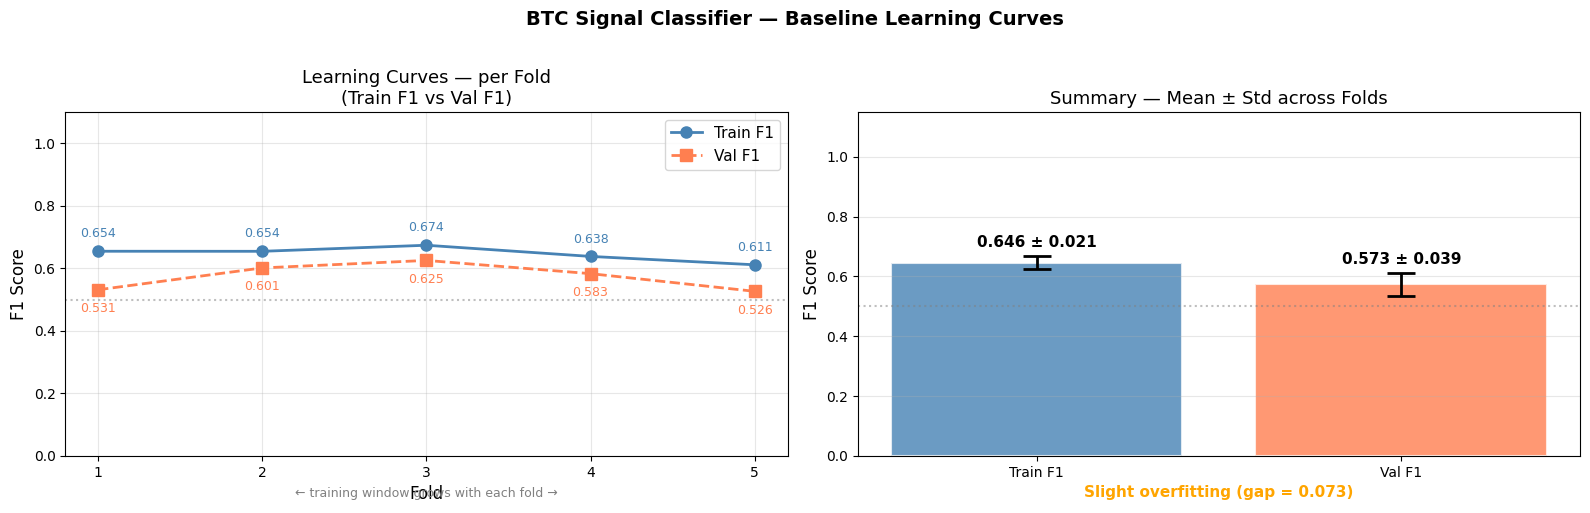

Train-Val gap: 0.073  →  Slight overfitting (gap = 0.073)


In [55]:
# ✅ Change 10 + 11: learning curves — per fold and summary

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

folds = list(range(1, len(fold_train_scores) + 1))


# ── Plot 1: Train F1 vs Val F1 per fold ────────────────────────────────────
ax1 = axes[0]

ax1.plot(folds, fold_train_scores,
         'o-', color='steelblue', linewidth=2, markersize=8, label='Train F1')
ax1.plot(folds, fold_val_scores,
         's--', color='coral', linewidth=2, markersize=8, label='Val F1')

for i, (tr, va) in enumerate(zip(fold_train_scores, fold_val_scores)):
    ax1.annotate(f'{tr:.3f}', (i + 1, tr),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=9, color='steelblue')
    ax1.annotate(f'{va:.3f}', (i + 1, va),
                 textcoords='offset points', xytext=(0, -16),
                 ha='center', fontsize=9, color='coral')

ax1.set_xlabel('Fold', fontsize=12)
ax1.set_ylabel('F1 Score', fontsize=12)
ax1.set_title('Learning Curves — per Fold\n(Train F1 vs Val F1)', fontsize=13)
ax1.set_xticks(folds)
ax1.set_ylim(0, 1.1)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Random baseline')
ax1.annotate('← training window grows with each fold →',
             xy=(0.5, -0.12), xycoords='axes fraction',
             ha='center', fontsize=9, color='gray')


# ── Plot 2: Summary — mean ± std across folds ──────────────────────────────
ax2 = axes[1]

mean_train = np.mean(fold_train_scores)
std_train  = np.std(fold_train_scores)
mean_val   = np.mean(fold_val_scores)
std_val    = np.std(fold_val_scores)

bars = ax2.bar(
    ['Train F1', 'Val F1'],
    [mean_train, mean_val],
    yerr=[std_train, std_val],
    color=['steelblue', 'coral'],
    alpha=0.8,
    capsize=10,
    edgecolor='white',
    linewidth=1.5,
    error_kw={'elinewidth': 2, 'ecolor': 'black', 'capthick': 2}
)

for bar, mean, std in zip(bars, [mean_train, mean_val], [std_train, std_val]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        mean + std + 0.02,
        f'{mean:.3f} ± {std:.3f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax2.set_ylabel('F1 Score', fontsize=12)
ax2.set_title('Summary — Mean ± Std across Folds', fontsize=13)
ax2.set_ylim(0, 1.15)
ax2.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
ax2.grid(True, alpha=0.3, axis='y')

# Overfitting verdict
gap = mean_train - mean_val
if gap > 0.15:
    verdict = f'Overfitting detected (gap = {gap:.3f})'
    color   = 'red'
elif gap > 0.05:
    verdict = f'Slight overfitting (gap = {gap:.3f})'
    color   = 'orange'
else:
    verdict = f'Good generalisation (gap = {gap:.3f})'
    color   = 'green'

ax2.text(0.5, -0.12, verdict,
         transform=ax2.transAxes,
         ha='center', fontsize=11, color=color, fontweight='bold')

plt.suptitle('BTC Signal Classifier — Baseline Learning Curves',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('learning_curves_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Train-Val gap: {gap:.3f}  →  {verdict}")

## 8 — Final Evaluation on Holdout Set

### ✅ Change 12 — Final model trained on full `X_train` → evaluated once on `X_holdout`

🔒 **`X_holdout` is opened here for the first and only time.**

The final model is retrained on the full `X_train` (all 5 folds combined) before evaluating on the holdout set. This gives the model the maximum available training data.

In [56]:
# ✅ Change 12: train final model on full X_train, evaluate once on X_holdout
# Previous: no holdout — no genuinely unseen final evaluation
# Now:      pipe.fit(X_train) → pipe.predict(X_holdout) — once, at the end

print("Training final model on full X_train...")
final_start = time.time()

#before:
#pipe.fit(X_train, y_train)

#now: Use mean best iteration from CV — avoids training all 1000 trees
mean_best_iter = int(np.mean(best_iterations))
print(f"Setting n_estimators = {mean_best_iter} (mean best iteration from CV folds)")

pipe.set_params(model__n_estimators = mean_best_iter)
pipe.fit(X_train, y_train)

final_elapsed = time.time() - final_start
print(f"Final model training time: {final_elapsed:.1f}s")

# 🔒 First and only time X_holdout is used
y_holdout_pred = pipe.predict(X_holdout)

print("\n" + "=" * 60)
print("FINAL EVALUATION — HOLDOUT SET")
print("(never seen during Walk-Forward CV)")
print("=" * 60)
print(f"Holdout period: {X_holdout.index[0].date()}  →  {X_holdout.index[-1].date()}")
print(f"Holdout bars:   {len(X_holdout):,}")
print("=" * 60 + "\n")

print(classification_report(
    y_holdout,
    y_holdout_pred,
    target_names=['FLAT (0)', 'BUY (1)']
))

Training final model on full X_train...
Setting n_estimators = 20 (mean best iteration from CV folds)
Final model training time: 0.2s

FINAL EVALUATION — HOLDOUT SET
(never seen during Walk-Forward CV)
Holdout period: 2024-07-19  →  2026-03-07
Holdout bars:   14,310

              precision    recall  f1-score   support

    FLAT (0)       0.51      0.55      0.53      7010
     BUY (1)       0.53      0.50      0.52      7300

    accuracy                           0.52     14310
   macro avg       0.52      0.52      0.52     14310
weighted avg       0.52      0.52      0.52     14310



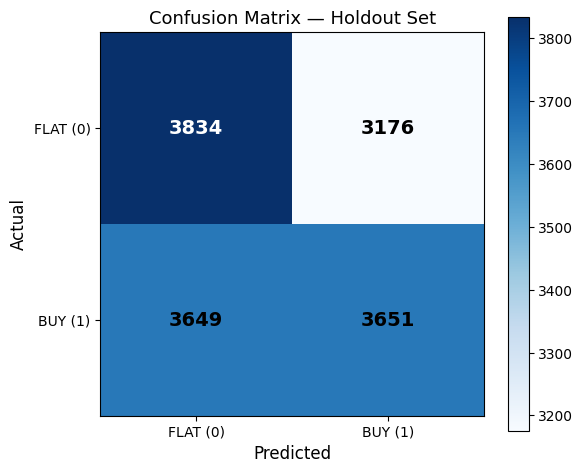

In [57]:
# Confusion Matrix — Holdout Set

cm = confusion_matrix(y_holdout, y_holdout_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)

tick_marks = [0, 1]
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(['FLAT (0)', 'BUY (1)'])
ax.set_yticklabels(['FLAT (0)', 'BUY (1)'])

for i in range(2):
    for j in range(2):
        ax.text(
            j, i, str(cm[i, j]),
            ha='center', va='center',
            color='white' if (i == 0 and j == 0) else 'black',
            fontsize=14, fontweight='bold'
        )

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix — Holdout Set', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix_holdout.png', dpi=150, bbox_inches='tight')
plt.show()

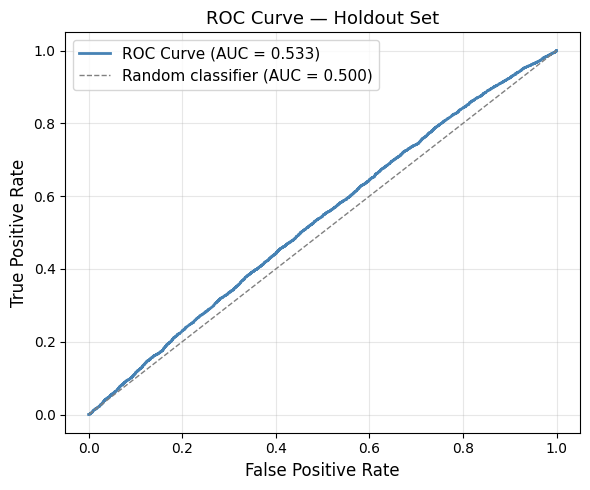

AUC Score: 0.533
AUC = 0.5 → random classifier
AUC = 1.0 → perfect classifier


In [58]:
# ROC Curve — Holdout Set
from sklearn.metrics import roc_curve, roc_auc_score

# predict_proba gives probability scores, not hard labels
# we use the probability of BUY (class 1) for the ROC curve
y_holdout_proba = pipe.predict_proba(X_holdout)[:, 1]

fpr, tpr, _ = roc_curve(y_holdout, y_holdout_proba)
auc = roc_auc_score(y_holdout, y_holdout_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'ROC Curve (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        linewidth=1, label='Random classifier (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Holdout Set', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_holdout.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC Score: {auc:.3f}")
print("AUC = 0.5 → random classifier")
print("AUC = 1.0 → perfect classifier")

In [59]:
# CV vs Holdout comparison — sanity check
# Holdout score is almost always lower than CV score
# A large gap between the two indicates overfitting to the training period

holdout_prec = precision_score(y_holdout, y_holdout_pred, zero_division=0)
holdout_rec  = recall_score(y_holdout, y_holdout_pred, zero_division=0)
holdout_f1   = f1_score(y_holdout, y_holdout_pred, zero_division=0)

print("CV vs Holdout — Sanity Check")
print("=" * 50)
print(f"Mean CV Val F1:     {np.mean(fold_val_scores):.3f} ± {np.std(fold_val_scores):.3f}")
print(f"Holdout F1:         {holdout_f1:.3f}")
print()
print(f"Mean CV Precision:  {metrics_df['Val Precision'].mean():.3f}")
print(f"Holdout Precision:  {holdout_prec:.3f}")
print()
cv_holdout_gap = np.mean(fold_val_scores) - holdout_f1
print(f"CV → Holdout gap:   {cv_holdout_gap:.3f}")
if cv_holdout_gap > 0.10:
    print("⚠️  Large gap — model may be overfitting to the 2018-2024 period")
else:
    print("✅  Small gap — model generalises reasonably across time periods")

CV vs Holdout — Sanity Check
Mean CV Val F1:     0.573 ± 0.039
Holdout F1:         0.517

Mean CV Precision:  0.541
Holdout Precision:  0.535

CV → Holdout gap:   0.056
✅  Small gap — model generalises reasonably across time periods
